In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone -b yolov8seg-baseline https://github.com/99anjalipai/Segment-Damage.git
%cd Segment-Damage

Cloning into 'Segment-Damage'...
remote: Enumerating objects: 182, done.
remote: Counting objects: 100% (182/182), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 182 (delta 63), reused 154 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (182/182), 8.77 MiB | 18.14 MiB/s, done.
Resolving deltas: 100% (63/63), done.
/content/Segment-Damage


In [6]:
!pip install -r requirements.txt
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 60.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 104.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.


In [4]:
!ls "/content/drive/MyDrive/SegmentDamage/yolo_results/yolov8n_seg_baseline2/weights"

best.pt  last.pt


In [16]:
!python tools/convert_masks_to_yolo_seg.py \
  --sod-root "/content/drive/MyDrive/SegmentDamage/CarDD_dataset/CarDD_SOD" \
  --splits-dir data/splits \
  --output-dir data/yolo_seg


Processing train...
train done. processed=1971, skipped=0

Processing val...
val done. processed=422, skipped=0

Processing test...
test done. processed=423, skipped=0


In [7]:
!python tools/evaluate_yolov8seg.py \
  --config configs/yolov8seg.yaml \
  --checkpoint "/content/drive/MyDrive/SegmentDamage/yolo_results/yolov8n_seg_baseline2/weights/best.pt" \
  --sod-root "/content/drive/MyDrive/SegmentDamage/CarDD_dataset/CarDD_SOD" \
  --splits-dir data/splits \
  --split val \
  --results-dir outputs/yolov8seg/eval/val \
  --tiny-thresh 5000 \
  --visualize-samples 5

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
{
  "mIoU": 0.6898953228595281,
  "IoU_per_class": [
    0.8345941131192895,
    0.5451965325997667
  ],
  "F1_proxy": 0.8164947420437063,
  "DET_l": 0.2857142857142857,
  "tiny_area_threshold": 5000,
  "tiny_samples": 7,
  "tiny_true_positive": 2,
  "tiny_false_negative": 5,
  "split": "val"
}
[Info] Metrics saved to outputs/yolov8seg/eval/val/metrics.json
[Stage] Saving evaluation visualizations to outputs/yolov8seg/eval/val/visualizations ...
[Info] Visualization saved to outputs/yolov8seg/eval/val/visualizations/eval_samples.png


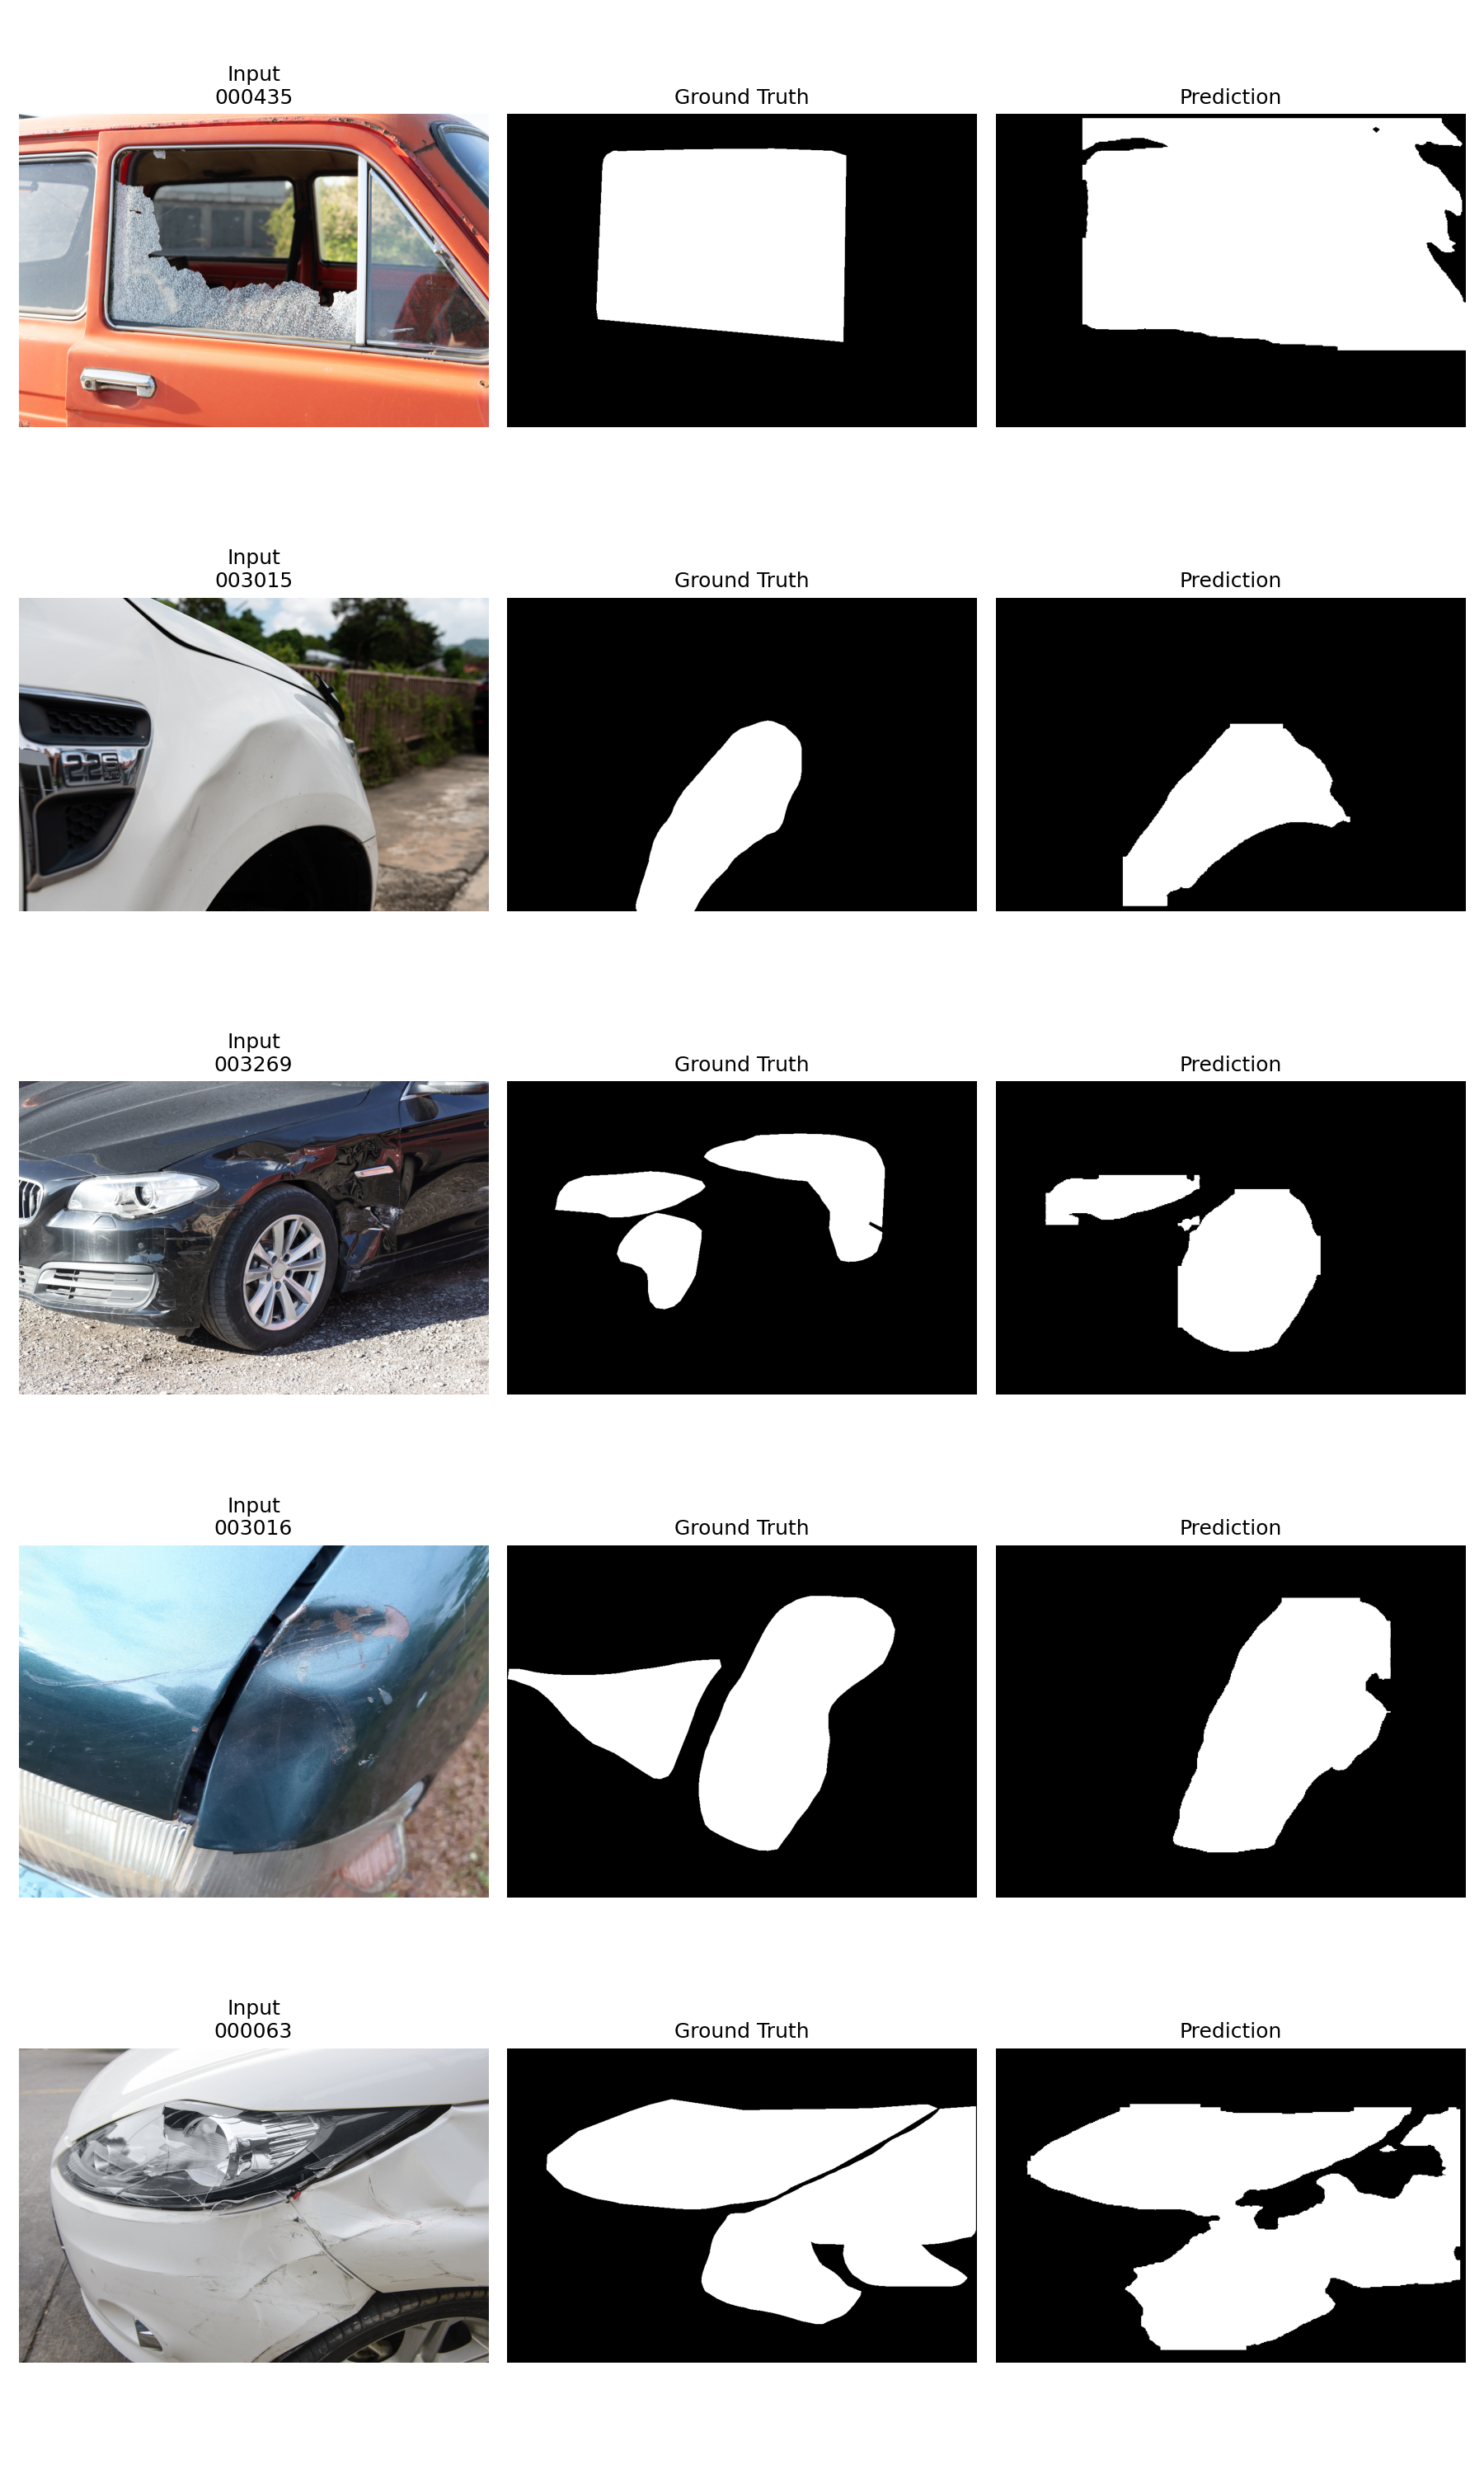

In [10]:
from IPython.display import Image, display
display(Image(filename="outputs/yolov8seg/eval/val/visualizations/eval_samples.png"))

In [ ]:
!python tools/train_yolov8seg.py --config configs/yolov8seg.yaml

Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/yolo_seg/cardd_yolov8seg.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_seg_baseline2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

In [ ]:
!ls runs/segment/outputs/yolov8seg
!ls runs/segment/outputs/yolov8seg/yolov8n_seg_baseline2/weights

yolov8n_seg_baseline  yolov8n_seg_baseline2
best.pt  last.pt


In [ ]:
!mkdir -p "/content/drive/MyDrive/SegmentDamage/yolo_results"
!cp -r runs/segment/outputs/yolov8seg/yolov8n_seg_baseline2 "/content/drive/MyDrive/SegmentDamage/yolo_results/"

In [ ]:
!ls "/content/drive/MyDrive/SegmentDamage/yolo_results/yolov8n_seg_baseline2/weights"

best.pt  last.pt


In [ ]:
!python tools/evaluate_yolov8seg.py \
  --config configs/yolov8seg.yaml \
  --checkpoint runs/segment/outputs/yolov8seg/yolov8n_seg_baseline2/weights/best.pt \
  --sod-root "/content/drive/MyDrive/SegmentDamage/CarDD_dataset/CarDD_SOD" \
  --splits-dir data/splits \
  --split val \
  --output-dir outputs/yolov8seg/eval/val \
  --tiny-thresh 5000

TINY sample: 000846, area=2713
TINY sample: 000510, area=3248
TINY sample: 002565, area=2596
TINY sample: 001973, area=1540
TINY sample: 000509, area=4160
TINY sample: 001950, area=3641
TINY sample: 002578, area=1651
{
  "split": "val",
  "mIoU": 0.6898953228595281,
  "IoU_per_class": [
    0.8345941131192895,
    0.5451965325997667
  ],
  "F1_proxy": 0.8164947420437063,
  "DET_l": 0.2857142857142857,
  "tiny_area_threshold": 5000,
  "tiny_samples": 7,
  "tiny_true_positive": 2,
  "tiny_false_negative": 5
}


In [ ]:
!mkdir -p outputs/yolov8seg/eval/test

!python tools/evaluate_yolov8seg.py \
  --config configs/yolov8seg.yaml \
  --checkpoint runs/segment/outputs/yolov8seg/yolov8n_seg_baseline2/weights/best.pt \
  --sod-root "/content/drive/MyDrive/SegmentDamage/CarDD_dataset/CarDD_SOD" \
  --splits-dir data/splits \
  --split test \
  --output-dir outputs/yolov8seg/eval/test \
  --tiny-thresh 5000

TINY sample: 001239, area=4018
TINY sample: 001447, area=1633
TINY sample: 002551, area=3515
TINY sample: 003396, area=4325
TINY sample: 001429, area=2667
TINY sample: 000813, area=4381
{
  "split": "test",
  "mIoU": 0.7172735352837301,
  "IoU_per_class": [
    0.836703179243216,
    0.5978438913242441
  ],
  "F1_proxy": 0.8353631737127087,
  "DET_l": 0.6666666666666666,
  "tiny_area_threshold": 5000,
  "tiny_samples": 6,
  "tiny_true_positive": 4,
  "tiny_false_negative": 2
}


In [19]:
!python tools/run_yolov8seg_optimizations.py


===== Running yolov8n_seg_512_e10 =====
Running: python tools/train_yolov8seg.py --config outputs/yolov8seg_optimizations/yolov8n_seg_512_e10.yaml
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/yolo_seg/cardd_yolov8seg.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.

In [ ]:
from google.colab import files
!zip -r yolo_code.zip tools configs data/yolo_seg/cardd_yolov8seg.yaml

  adding: tools/ (stored 0%)
  adding: tools/train_week1.py (deflated 72%)
  adding: tools/evaluate_week1.py (deflated 66%)
  adding: tools/train_yolov8seg.py (deflated 57%)
  adding: tools/prepare_cardd_splits.py (deflated 62%)
  adding: tools/evaluate_yolov8seg.py (deflated 66%)
  adding: tools/run_baseline_overnight.sh (deflated 61%)
  adding: tools/convert_masks_to_yolo_seg.py (deflated 68%)
  adding: tools/run_baseline_optimizations.py (deflated 75%)
  adding: configs/ (stored 0%)
  adding: configs/week1_unet.yaml (deflated 57%)
  adding: configs/feature_projector_ce_dice_focal_grad.yaml (deflated 58%)
  adding: configs/yolov8seg.yaml (deflated 38%)
  adding: configs/baseline_optimizations.yaml (deflated 89%)
  adding: data/yolo_seg/cardd_yolov8seg.yaml (stored 0%)


In [ ]:
files.download("yolo_code.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>